In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Path to the file
file_path = "adult.csv"

# Load the latest version
df_raw = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "wenruliu/adult-income-dataset",
  file_path,
)

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

/tmp/ipykernel_14637/313580826.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_raw = kagglehub.load_dataset(


100%|██████████| 652k/652k [00:00<00:00, 46.0MB/s]

Extracting zip of adult.csv...


Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
# Split BEFORE any processing — test data is never touched during EDA/cleaning
df_train, df_test = train_test_split(df_raw, test_size=0.30, random_state=42, stratify=df_raw['income'])

print(f'Training set size : {df_train.shape[0]:,} rows ({df_train.shape[0]/len(df_raw)*100:.1f}%)')
print(f'Testing  set size : {df_test.shape[0]:,} rows ({df_test.shape[0]/len(df_raw)*100:.1f}%)')

# Save test set aside — untouched
df_test_untouched = df_test.copy()
print('\nClass distribution in training set:')
print(df_train['income'].value_counts(normalize=True).round(3))

Training set size : 34,189 rows (70.0%)
Testing  set size : 14,653 rows (30.0%)

Class distribution in training set:
income
<=50K   0.76
>50K    0.24
Name: proportion, dtype: float64


In [4]:
print('=== Training Set Overview ===')
print(f'Shape: {df_train.shape}')
print(f'\nData types:\n{df_train.dtypes}')
print(f'\nBasic statistics:')
df_train.describe()

=== Training Set Overview ===
Shape: (34189, 15)

Data types:
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

Basic statistics:


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,34189.00,34189.00,34189.00,34189.00,34189.00,34189.00
mean,38.71,189651.77,10.08,1050.98,89.10,40.48
std,13.71,104982.75,2.57,7281.75,406.10,12.43
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117789.00,9.00,0.00,0.00,40.00
50%,37.00,178282.00,10.00,0.00,0.00,40.00
75%,48.00,237433.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [5]:
# Identify disguised missing values ('?')
print('=== Missing / ? Values in Training Set ===')
df_train_copy = df_train.copy()
df_train_copy.replace('?', np.nan, inplace=True)

missing = df_train_copy.isnull().sum()
missing_pct = (df_train_copy.isnull().sum() / len(df_train_copy) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

=== Missing / ? Values in Training Set ===
                Missing Count  Missing %
workclass                1926       5.63
occupation               1936       5.66
native-country            590       1.73


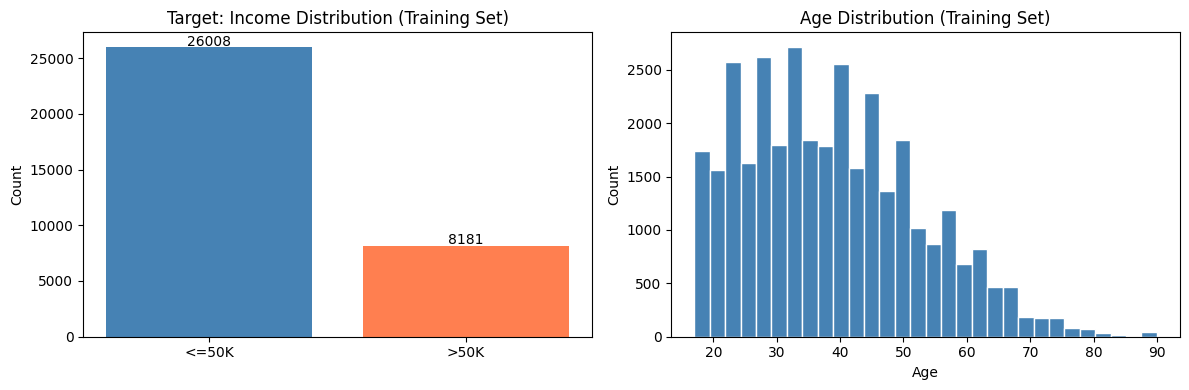

Chart saved.


In [6]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

income_counts = df_train['income'].value_counts()
axes[0].bar(income_counts.index, income_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Target: Income Distribution (Training Set)')
axes[0].set_ylabel('Count')
for i, v in enumerate(income_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center')

# Age distribution
axes[1].hist(df_train['age'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution (Training Set)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved.')

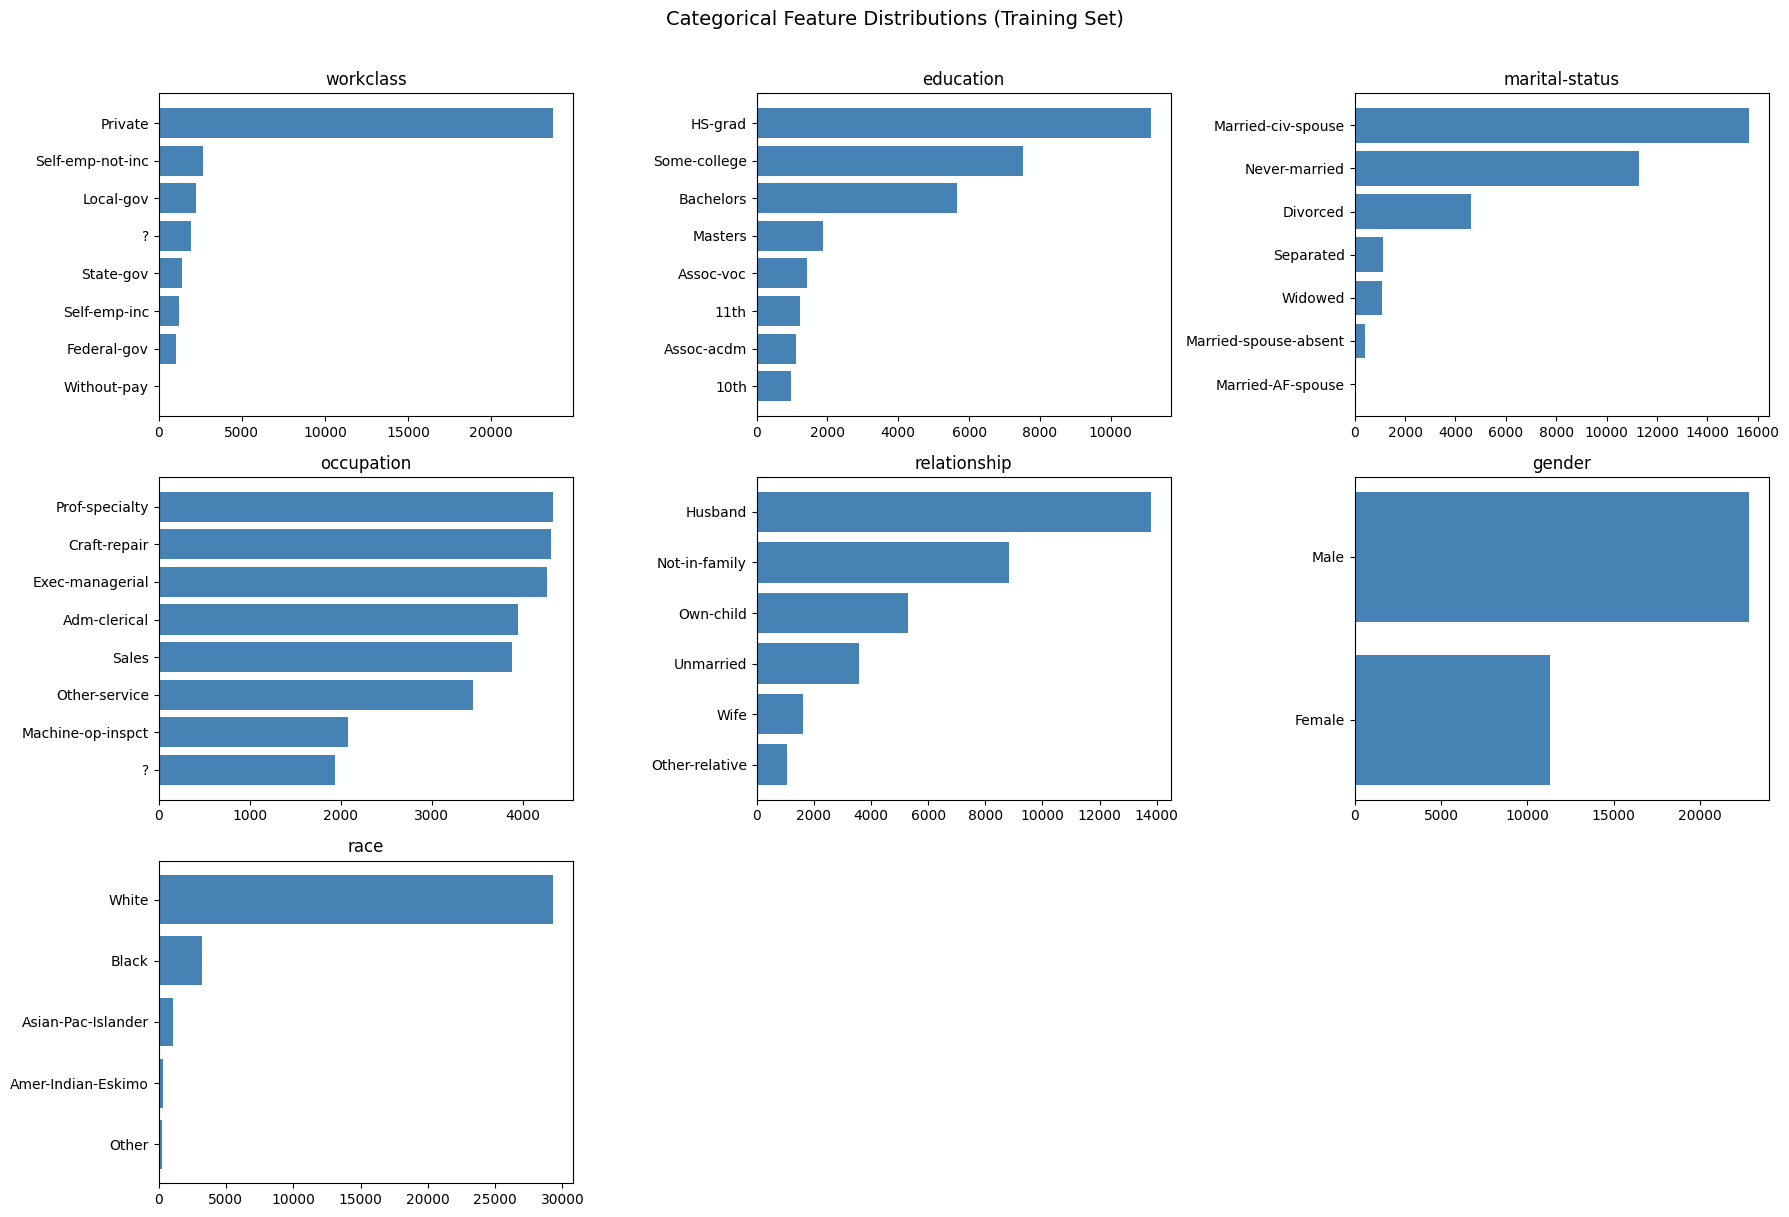

In [7]:
# Categorical feature exploration
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'gender', 'race']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_train[col].value_counts().head(8)
    axes[i].barh(counts.index, counts.values, color='steelblue')
    axes[i].set_title(f'{col}')
    axes[i].invert_yaxis()

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions (Training Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=100, bbox_inches='tight')
plt.show()

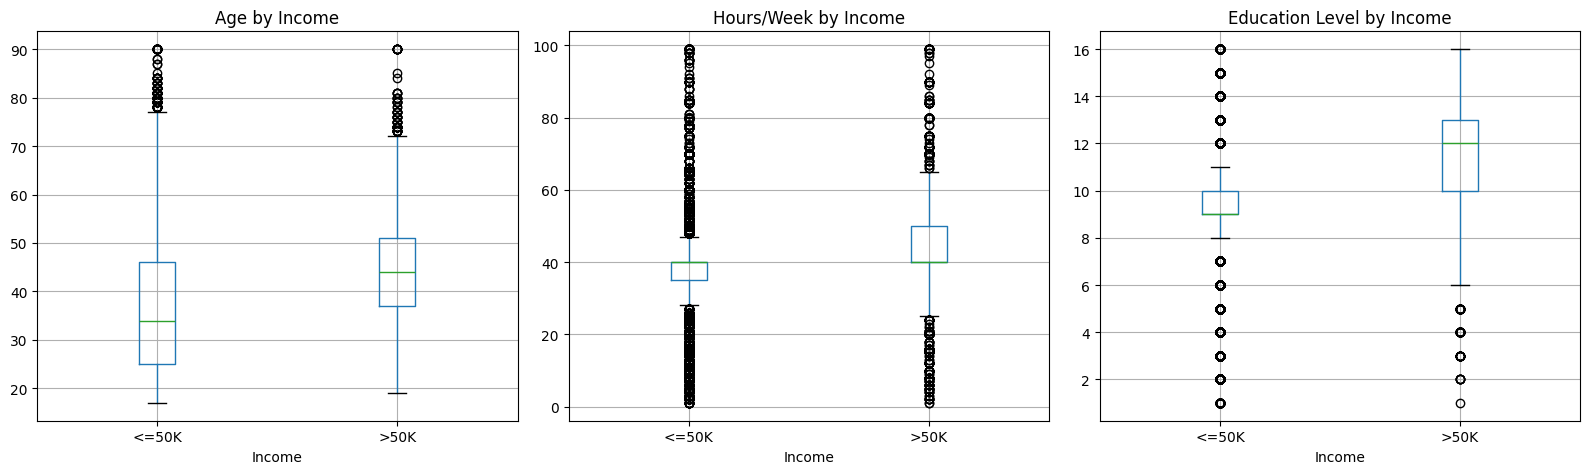

In [8]:
# Income by key features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age by income
df_train.boxplot(column='age', by='income', ax=axes[0])
axes[0].set_title('Age by Income')
axes[0].set_xlabel('Income')

# Hours per week by income
df_train.boxplot(column='hours-per-week', by='income', ax=axes[1])
axes[1].set_title('Hours/Week by Income')
axes[1].set_xlabel('Income')

# Education num by income
df_train.boxplot(column='educational-num', by='income', ax=axes[2])
axes[2].set_title('Education Level by Income')
axes[2].set_xlabel('Income')

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_income_features.png', dpi=100, bbox_inches='tight')
plt.show()

**Data Cleaning**

In [9]:
# Data cleaning on copy of training data
df_clean = df_train.copy()

print('=== BEFORE Cleaning ===')
print('Sample rows with ? values:')
print(df_clean[df_clean['workclass'] == '?'][['age','workclass','occupation','native-country','income']].head(5))

# Replace '?' with NaN
df_clean.replace('?', np.nan, inplace=True)

# Fill NaN with mode from training set
cols_with_missing = ['workclass', 'occupation', 'native-country']
fill_values = {}
for col in cols_with_missing:
    mode_val = df_clean[col].mode()[0]
    fill_values[col] = mode_val
    df_clean[col].fillna(mode_val, inplace=True)
    print(f'Filled "{col}" NaN with mode: "{mode_val}"')

print(f'\nRemaining nulls after cleaning: {df_clean.isnull().sum().sum()}')

=== BEFORE Cleaning ===
Sample rows with ? values:
       age workclass occupation native-country income
17212   19         ?          ?  United-States  <=50K
9312    32         ?          ?  United-States  <=50K
12616   47         ?          ?  United-States  <=50K
2547    51         ?          ?          South  <=50K
27636   73         ?          ?  United-States  <=50K
Filled "workclass" NaN with mode: "Private"
Filled "occupation" NaN with mode: "Prof-specialty"
Filled "native-country" NaN with mode: "United-States"

Remaining nulls after cleaning: 0


In [10]:
print('=== AFTER Cleaning — No More ? / NaN ===')
print(df_clean[['workclass','occupation','native-country']].isnull().sum())
print()
print('workclass value counts (? gone):')
print(df_clean['workclass'].value_counts())

=== AFTER Cleaning — No More ? / NaN ===
workclass         0
occupation        0
native-country    0
dtype: int64

workclass value counts (? gone):
workclass
Private             25635
Self-emp-not-inc     2681
Local-gov            2239
State-gov            1383
Self-emp-inc         1209
Federal-gov          1016
Without-pay            16
Never-worked           10
Name: count, dtype: int64


In [11]:
numeric_cols = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

print('=== BEFORE Scaling ===')
print(df_clean[numeric_cols].describe().loc[['min','max','mean']])

# Apply MinMax scaling
scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

print('\n=== AFTER Min-Max Scaling (range now 0 to 1) ===')
print(df_scaled[numeric_cols].describe().loc[['min','max','mean']])

=== BEFORE Scaling ===
       age     fnlwgt  educational-num  capital-gain  capital-loss  \
min  17.00   12285.00             1.00          0.00          0.00   
max  90.00 1484705.00            16.00      99999.00       4356.00   
mean 38.71  189651.77            10.08       1050.98         89.10   

      hours-per-week  
min             1.00  
max            99.00  
mean           40.48  

=== AFTER Min-Max Scaling (range now 0 to 1) ===
      age  fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week
min  0.00    0.00             0.00          0.00          0.00            0.00
max  1.00    1.00             1.00          1.00          1.00            1.00
mean 0.30    0.12             0.61          0.01          0.02            0.40


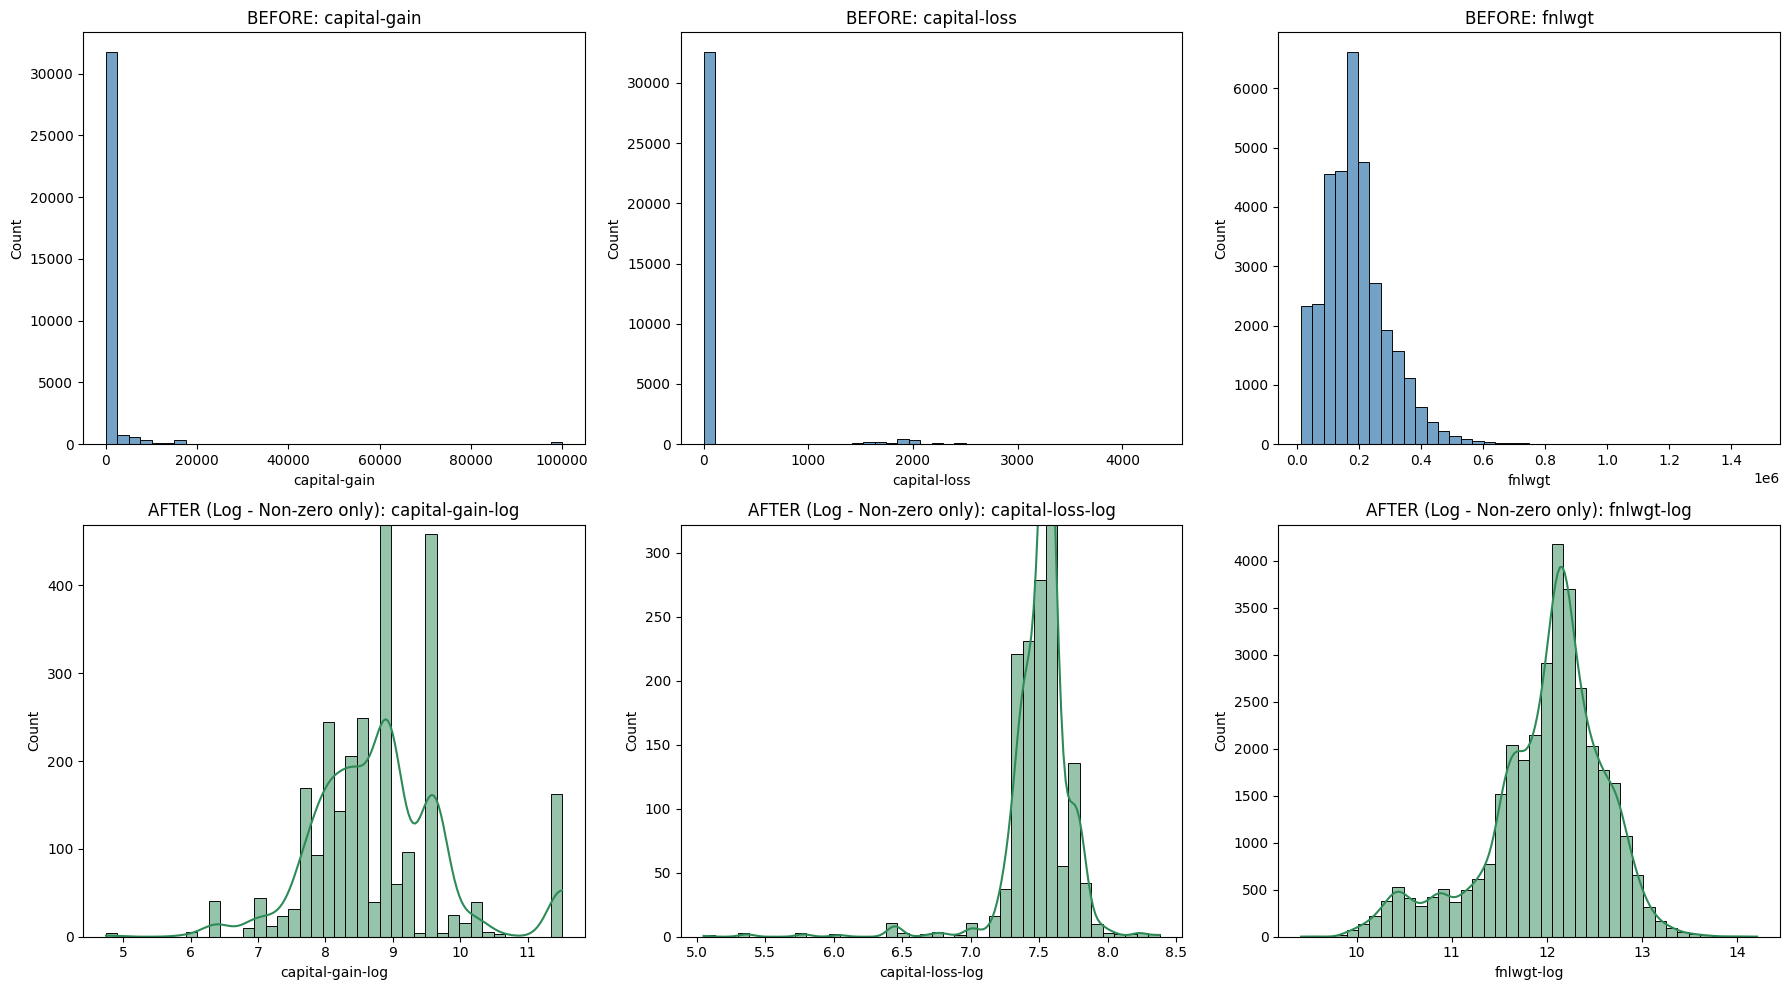

In [12]:
# Apply Log Transformation
df_clean['capital-gain-log'] = np.log1p(df_clean['capital-gain'])
df_clean['capital-loss-log'] = np.log1p(df_clean['capital-loss'])
df_clean['fnlwgt-log'] = np.log1p(df_clean['fnlwgt'])

# Update df_normalized
df_normalized = df_clean.copy()
df_normalized.drop(['capital-gain', 'capital-loss', 'fnlwgt'], axis=1, inplace=True)

# Visualize the "Before vs After"
skewed_cols = ['capital-gain', 'capital-loss', 'fnlwgt']
log_cols = ['capital-gain-log', 'capital-loss-log', 'fnlwgt-log']

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

skewed_cols = ['capital-gain', 'capital-loss', 'fnlwgt']
log_cols = ['capital-gain-log', 'capital-loss-log', 'fnlwgt-log']

for i, col in enumerate(skewed_cols):
    # --- BEFORE (Top Row) ---
    sns.histplot(df_clean[col], bins=40, kde=False, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'BEFORE: {col}')

    # --- AFTER (Bottom Row) ---
    # We filter out the 0s just for the graph so we can see the distribution of actual values
    data_filtered = df_clean[df_clean[log_cols[i]] > 0][log_cols[i]]

    sns.histplot(data_filtered, bins=40, kde=True, ax=axes[1, i], color='seagreen')
    axes[1, i].set_title(f'AFTER (Log - Non-zero only): {log_cols[i]}')

    # Zoom in on the Y-axis if the counts are still too varied
    if i < 2: # For gain and loss
        axes[1, i].set_ylim(0, data_filtered.value_counts().max() + 100)

plt.tight_layout()
plt.show()

In [13]:
df_encoded = df_normalized.copy()

print('=== BEFORE Label Encoding ===')
print(df_encoded[['gender', 'income']].head(5))

# Label encode binary columns
le = LabelEncoder()
binary_cols = ['gender', 'income']
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col} mapping: {mapping}')

print('\n=== AFTER Label Encoding ===')
print(df_encoded[['gender', 'income']].head(5))

=== BEFORE Label Encoding ===
       gender income
38865    Male  <=50K
17212  Female  <=50K
9312     Male  <=50K
15512    Male  <=50K
23576    Male  <=50K
  gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
  income mapping: {'<=50K': np.int64(0), '>50K': np.int64(1)}

=== AFTER Label Encoding ===
       gender  income
38865       1       0
17212       0       0
9312        1       0
15512       1       0
23576       1       0


In [14]:
ohe_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

print(f'=== BEFORE One-Hot Encoding ===')
print(f'Shape: {df_encoded.shape}')
print(df_encoded[ohe_cols].head(3))

# One-Hot Encode
df_ohe = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

print(f'\n=== AFTER One-Hot Encoding ===')
print(f'Shape: {df_ohe.shape} (columns expanded from {df_encoded.shape[1]} to {df_ohe.shape[1]})')
print('New columns added (sample):')
new_cols = [c for c in df_ohe.columns if any(c.startswith(cat) for cat in ohe_cols)]
print(new_cols[:15], '...')

=== BEFORE One-Hot Encoding ===
Shape: (34189, 15)
      workclass     education      marital-status        occupation  \
38865   Private       HS-grad       Never-married  Transport-moving   
17212   Private  Some-college       Never-married    Prof-specialty   
9312    Private       HS-grad  Married-civ-spouse    Prof-specialty   

        relationship   race native-country  
38865  Not-in-family  White  United-States  
17212      Own-child  White  United-States  
9312         Husband  Black  United-States  

=== AFTER One-Hot Encoding ===
Shape: (34189, 98) (columns expanded from 15 to 98)
New columns added (sample):
['educational-num', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm'] ...


In [15]:
df_feat = df_ohe.copy()

# NOTE: age and hours-per-week are scaled (0-1). Use original df_clean for engineering then re-scale.
# For clarity, we reconstruct from original training values:
df_feat_check = df_clean.copy()
df_feat_check.replace('?', np.nan, inplace=True)
for col in cols_with_missing:
    df_feat_check[col].fillna(fill_values[col], inplace=True)

# Feature 1: capital_net = capital.gain - capital.loss
df_feat['capital_net'] = df_feat_check['capital-gain'] - df_feat_check['capital-loss']
print('Feature 1 — capital_net (capital gain minus capital loss):')
print(df_feat['capital_net'].describe())

# Feature 2: age_group — bin age into life stages
df_feat['age_group'] = pd.cut(
    df_feat_check['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['Young', 'EarlyCareer', 'MidCareer', 'LateCareer', 'Senior']
)
df_feat['age_group'] = LabelEncoder().fit_transform(df_feat['age_group'].astype(str))
print('\nFeature 2 — age_group value counts:')
print(df_feat['age_group'].value_counts())

# Feature 3: is_high_hours — binary flag for people working more than 45 hrs/week
df_feat['is_high_hours'] = (df_feat_check['hours-per-week'] > 45).astype(int)
print('\nFeature 3 — is_high_hours (>45 hrs/week):')
print(df_feat['is_high_hours'].value_counts())

print(f'\nFinal dataset shape after feature engineering: {df_feat.shape}')

Feature 1 — capital_net (capital gain minus capital loss):
count   34189.00
mean      961.88
std      7305.89
min     -4356.00
25%         0.00
50%         0.00
75%         0.00
max     99999.00
Name: capital_net, dtype: float64

Feature 2 — age_group value counts:
age_group
2    11711
0     8878
4     6687
1     5658
3     1255
Name: count, dtype: int64

Feature 3 — is_high_hours (>45 hrs/week):
is_high_hours
0    26616
1     7573
Name: count, dtype: int64

Final dataset shape after feature engineering: (34189, 101)


In [16]:
summary = {
    'Stage': [
        'Raw Dataset',
        'After Train/Test Split (train)',
        'After Cleaning (? -> mode)',
        'After Scaling (MinMax)',
        'After Normalization (Z-score)',
        'After Label Encoding',
        'After One-Hot Encoding',
        'After Feature Engineering'
    ],
    'Rows': [
        df_raw.shape[0],
        df_train.shape[0],
        df_clean.shape[0],
        df_scaled.shape[0],
        df_normalized.shape[0],
        df_encoded.shape[0],
        df_ohe.shape[0],
        df_feat.shape[0]
    ],
    'Columns': [
        df_raw.shape[1],
        df_train.shape[1],
        df_clean.shape[1],
        df_scaled.shape[1],
        df_normalized.shape[1],
        df_encoded.shape[1],
        df_ohe.shape[1],
        df_feat.shape[1]
    ],
    'Missing Values': [
        df_raw.replace('?', np.nan).isnull().sum().sum(),
        df_train.replace('?', np.nan).isnull().sum().sum(),
        df_clean.isnull().sum().sum(),
        df_scaled.isnull().sum().sum(),
        df_normalized.isnull().sum().sum(),
        df_encoded.isnull().sum().sum(),
        df_ohe.isnull().sum().sum(),
        df_feat.isnull().sum().sum()
    ]
}

summary_df = pd.DataFrame(summary)
print('=== Dataset Transformation Summary ===')
print(summary_df.to_string(index=False))

=== Dataset Transformation Summary ===
                         Stage  Rows  Columns  Missing Values
                   Raw Dataset 48842       15            6465
After Train/Test Split (train) 34189       15            4452
    After Cleaning (? -> mode) 34189       18               0
        After Scaling (MinMax) 34189       15               0
 After Normalization (Z-score) 34189       15               0
          After Label Encoding 34189       15               0
        After One-Hot Encoding 34189       98               0
     After Feature Engineering 34189      101               0


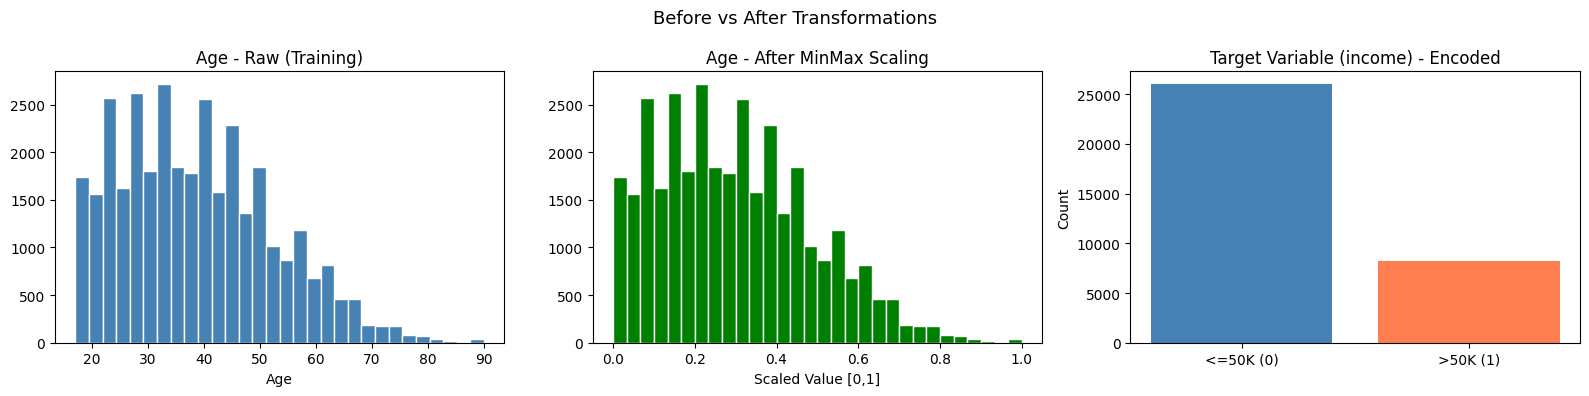

In [17]:
# Visual comparison: age column before and after scaling
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Before scaling
axes[0].hist(df_clean['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age - Raw (Training)')
axes[0].set_xlabel('Age')

# After MinMax scaling
axes[1].hist(df_scaled['age'], bins=30, color='green', edgecolor='white')
axes[1].set_title('Age - After MinMax Scaling')
axes[1].set_xlabel('Scaled Value [0,1]')

# Income class balance
income_map = {'<=50K': 0, '>50K': 1}
income_encoded = df_train['income'].map(income_map)
axes[2].bar(['<=50K (0)', '>50K (1)'], income_encoded.value_counts().sort_index().values,
            color=['steelblue', 'coral'])
axes[2].set_title('Target Variable (income) - Encoded')
axes[2].set_ylabel('Count')

plt.suptitle('Before vs After Transformations', fontsize=13)
plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

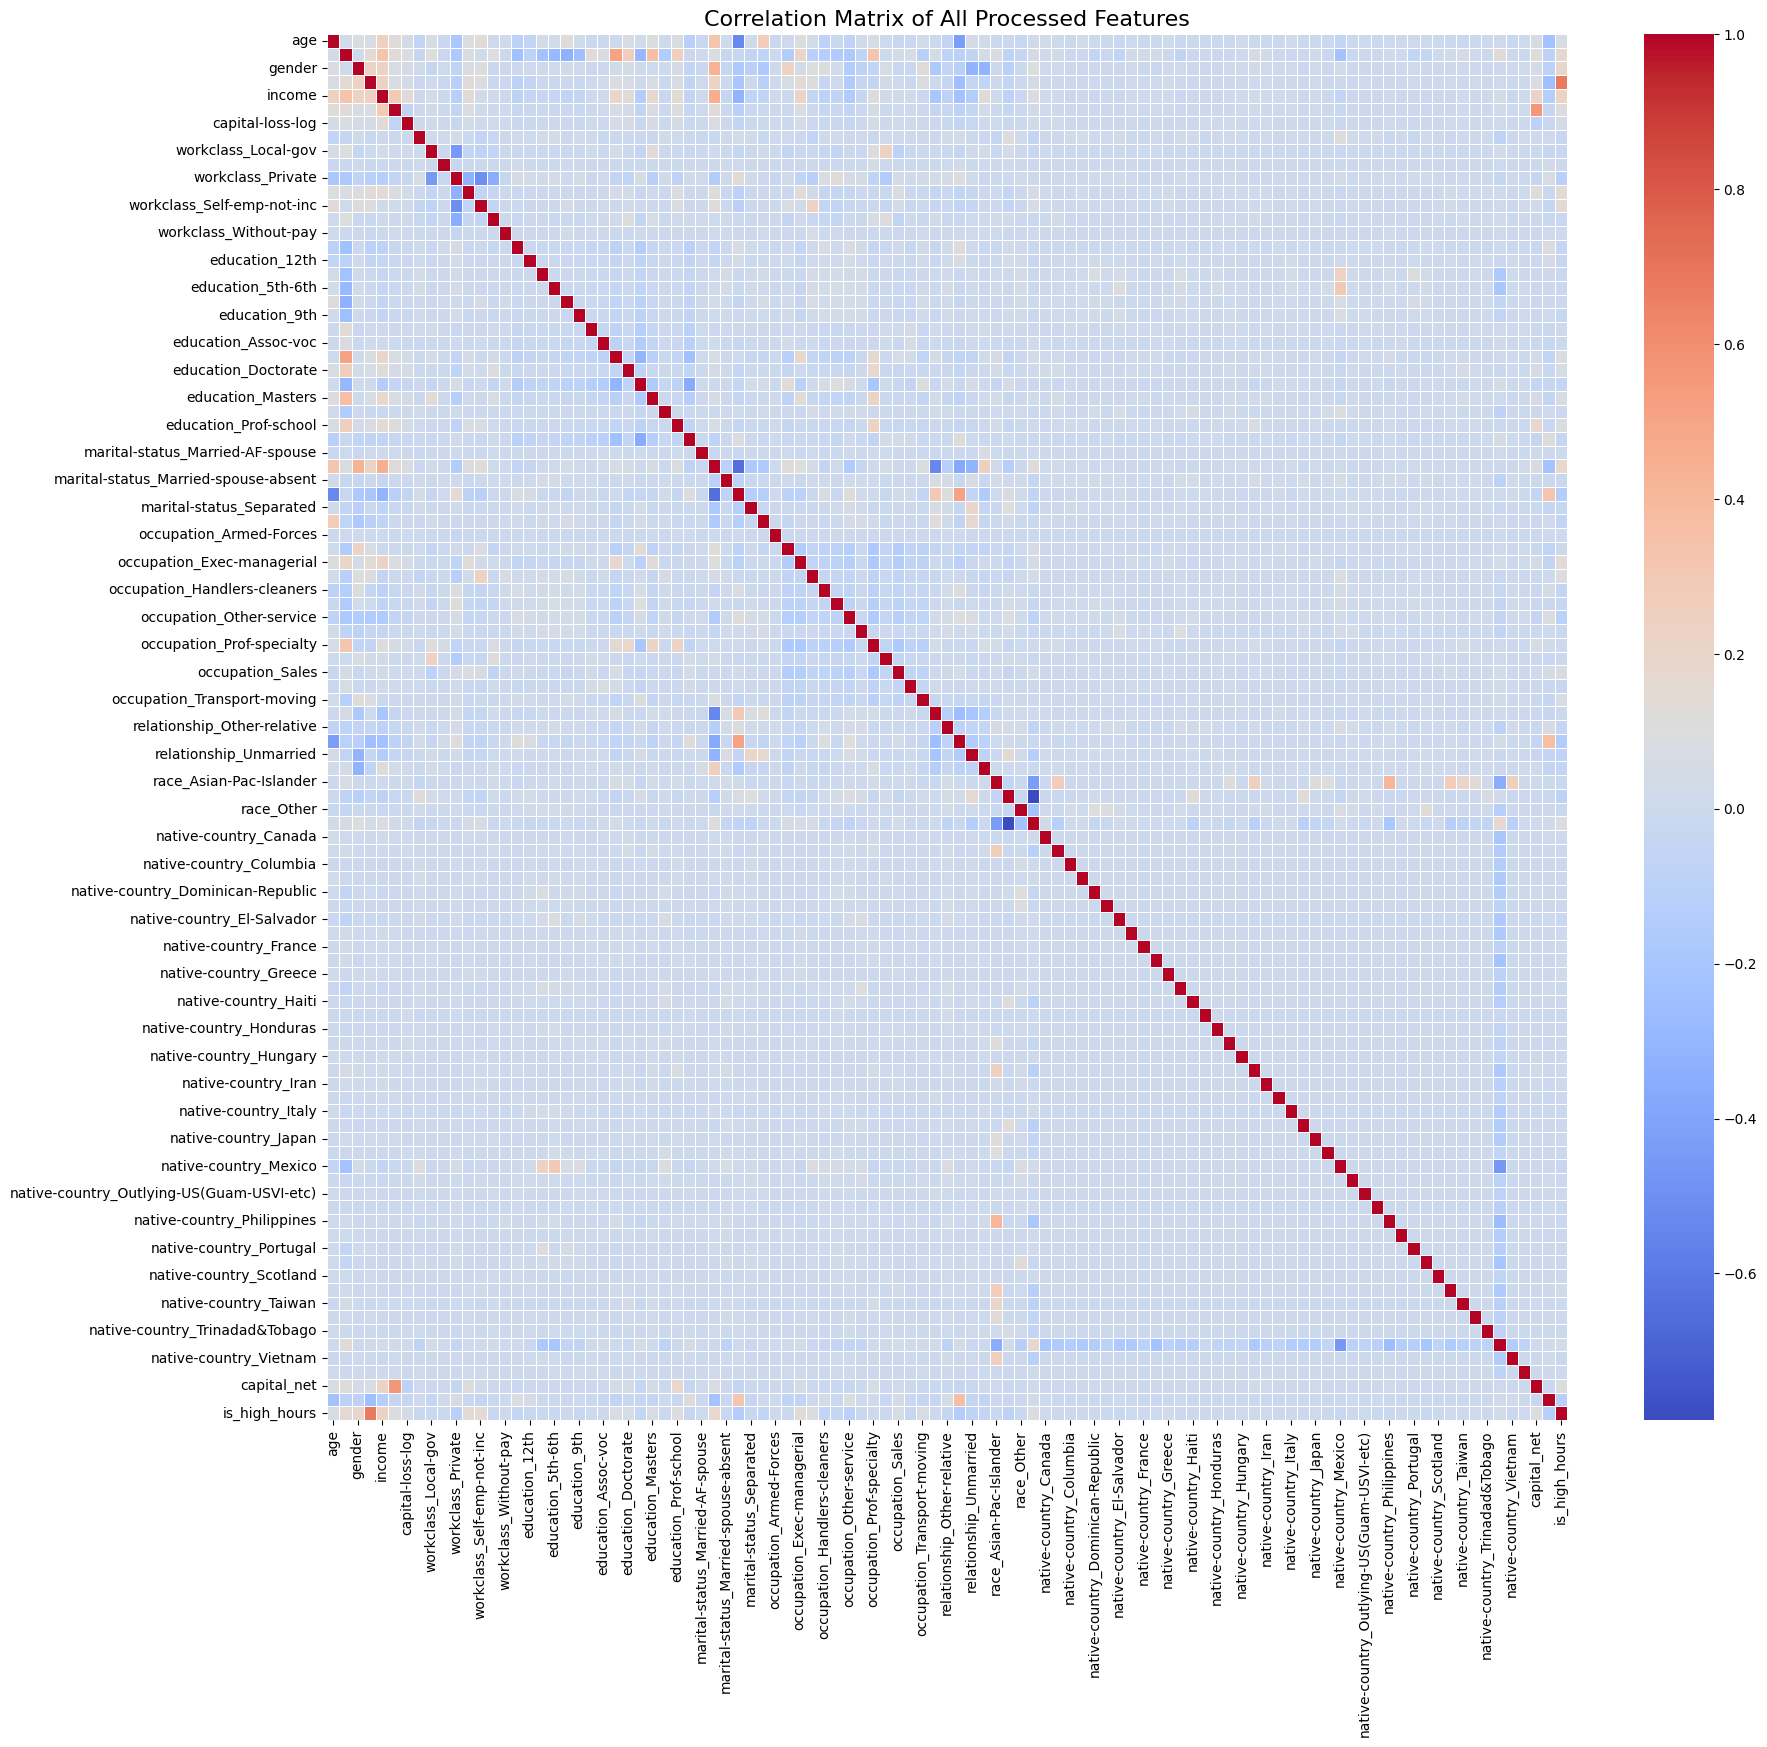


=== Correlations with Income ===
Top 10 Positive Correlations:
income                              1.00
marital-status_Married-civ-spouse   0.45
educational-num                     0.33
capital-gain-log                    0.29
age                                 0.23
hours-per-week                      0.22
is_high_hours                       0.22
gender                              0.22
occupation_Exec-managerial          0.22
capital_net                         0.21
Name: income, dtype: float64

Top 10 Negative Correlations:
occupation_Handlers-cleaners   -0.09
race_Black                     -0.09
workclass_Private              -0.12
age_group                      -0.13
education_HS-grad              -0.13
relationship_Unmarried         -0.15
occupation_Other-service       -0.16
relationship_Not-in-family     -0.19
relationship_Own-child         -0.22
marital-status_Never-married   -0.32
Name: income, dtype: float64


In [18]:
plt.figure(figsize=(20, 18))
sns.heatmap(df_feat.corr(), cmap='coolwarm', fmt=".2f", annot=False, linewidths=.5)
plt.title('Correlation Matrix of All Processed Features', fontsize=16)
plt.show()


# Calculate correlation matrix
correlation_matrix = df_feat.corr()

# Extract correlations with 'income' and sort them
income_correlations = correlation_matrix['income'].sort_values(ascending=False)

print('\n=== Correlations with Income ===')
print('Top 10 Positive Correlations:')
print(income_correlations.head(10))

print('\nTop 10 Negative Correlations:')
print(income_correlations.tail(10))


**Final Dataset**

In [19]:
# Export clean training data
df_feat.to_csv('adult_income_clean_train.csv', index=False)
print(f'Clean training dataset saved: adult_income_clean_train.csv')
print(f'Shape: {df_feat.shape}')

# Save untouched test set
df_test_untouched.to_csv('adult_income_test_raw.csv', index=False)
print(f'\nUntouched test dataset saved: adult_income_test_raw.csv')
print(f'Shape: {df_test_untouched.shape}')

print('\nFirst 3 rows of clean training data:')
df_feat.head(3)

Clean training dataset saved: adult_income_clean_train.csv
Shape: (34189, 101)

Untouched test dataset saved: adult_income_test_raw.csv
Shape: (14653, 15)

First 3 rows of clean training data:


,age,educational-num,gender,hours-per-week,income,capital-gain-log,capital-loss-log,fnlwgt-log,workclass_Local-gov,workclass_Never-worked,...,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,capital_net,age_group,is_high_hours
38865,21,9,1,60,0,0.00,0.00,12.67,False,False,...,False,False,False,False,True,False,False,0,4,1
17212,19,10,0,10,0,0.00,0.00,10.86,False,False,...,False,False,False,False,True,False,False,0,4,0
9312,32,9,1,45,0,0.00,0.00,12.74,False,False,...,False,False,False,False,True,False,False,0,0,0


**Analysis: Classification**

In [20]:
# Define Features (X) and Target (y)
X = df_feat.drop('income', axis=1)
y = df_feat['income']

# Data Split from 70/30 to 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]} | Val size: {X_val.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 23932 | Val size: 5128 | Test size: 5129


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [22]:
# Classification Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True) # probability=True is needed for ROC-AUC
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    # Evaluate
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob)
    })

df_results = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
display(df_results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,0.85,0.68,0.67,0.67,0.89
3,Gradient Boosting,0.86,0.76,0.60,0.67,0.92
2,Random Forest,0.84,0.70,0.61,0.65,0.90
4,KNN,0.84,0.66,0.64,0.65,0.87
0,Logistic Regression,0.84,0.71,0.55,0.62,0.89
5,SVC,0.80,0.72,0.28,0.40,0.84


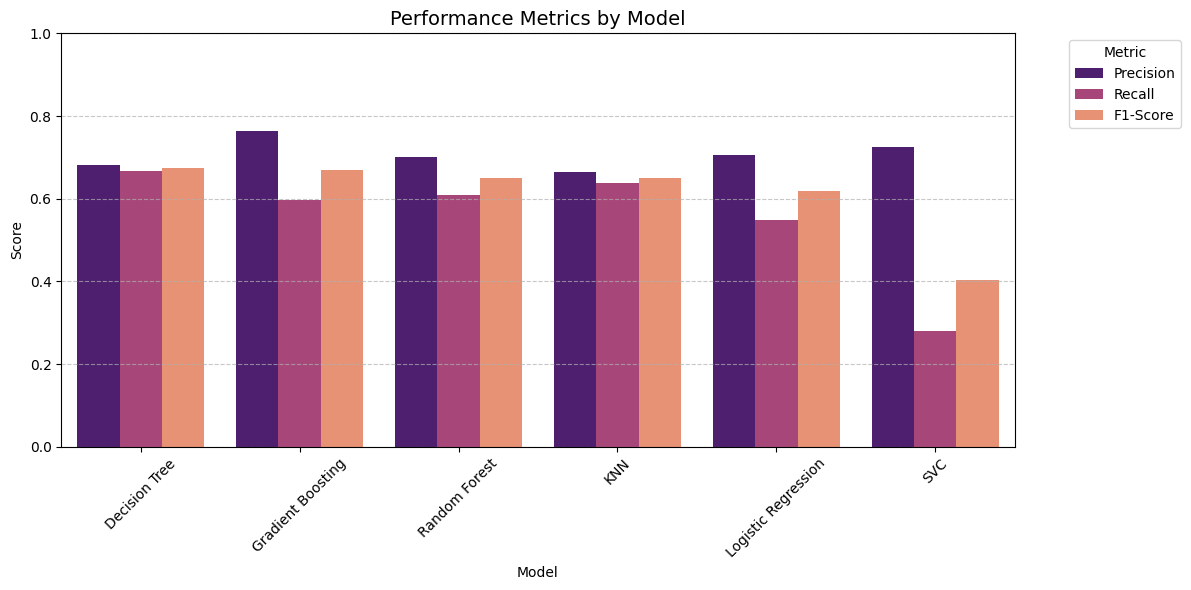

In [25]:
# Filter to the base models for a clean comparison of all metrics
base_metrics = df_results.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1-Score'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='value', hue='variable', data=base_metrics, palette='magma')
plt.title('Performance Metrics by Model', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=45)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

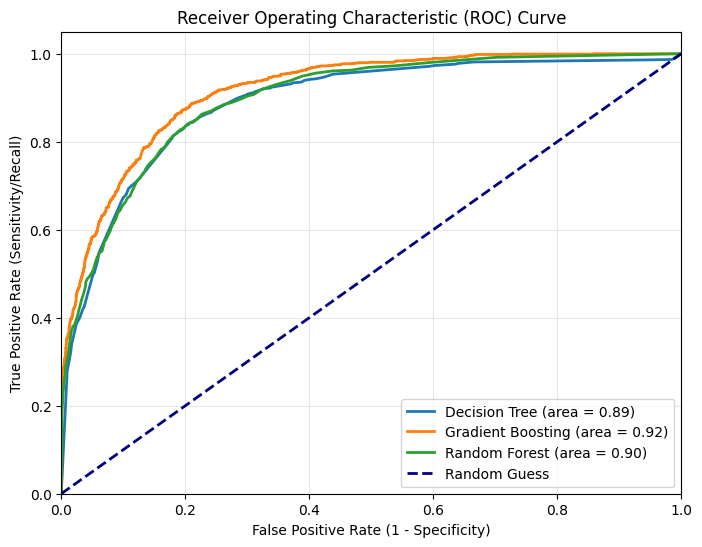

In [27]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

# Plotting the curve for your top 3 models
for name in top_3_names:
    model = models[name]
    # Use the validation set probabilities we calculated earlier
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (area = {roc_auc:.2f})')

# The "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [23]:
from sklearn.ensemble import VotingClassifier

# Get top 3 models based on F1-Score
top_3_names = df_results.iloc[:3]['Model'].values
estimators = [(name, models[name]) for name in top_3_names]

# Create Voting Classifier
voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train, y_train)

# Evaluate on Test Set
test_pred = voting_clf.predict(X_test)
test_prob = voting_clf.predict_proba(X_test)[:, 1]

print(f"Ensemble Test Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"Ensemble Test ROC-AUC: {roc_auc_score(y_test, test_prob):.4f}")

Ensemble Test Accuracy: 0.8645
Ensemble Test ROC-AUC: 0.9185


In [24]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import BayesianRidge, LogisticRegression

# Using a Stacking Classifier with a Bayesian-style final estimator
# Note: BayesianRidge is for regression, so we use LogisticRegression as a standard meta-classifier
stack_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack_clf.fit(X_train, y_train)

stack_pred = stack_clf.predict(X_test)
print(f"Bayesian Stacking Test Accuracy: {accuracy_score(y_test, stack_pred):.4f}")

Bayesian Stacking Test Accuracy: 0.8666


<Figure size 800x600 with 0 Axes>

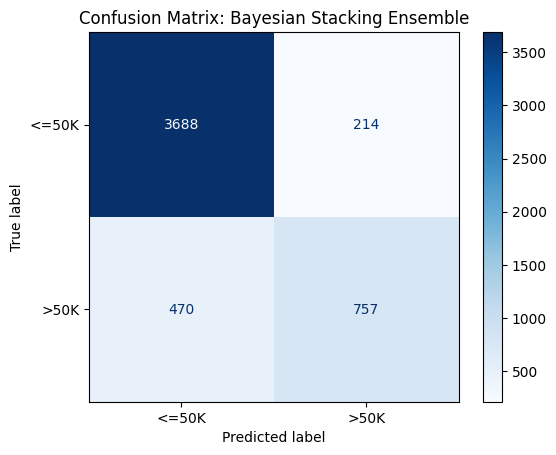

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix for your best model
cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Bayesian Stacking Ensemble')
plt.show()

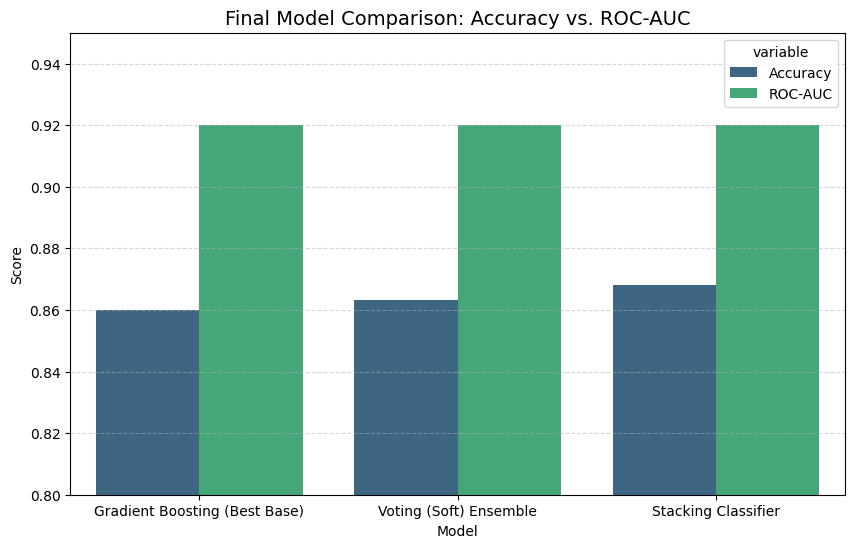

In [26]:
# Create a small DataFrame for the final comparison
final_comparison = pd.DataFrame([
    {"Model": "Gradient Boosting (Best Base)", "Accuracy": 0.86, "ROC-AUC": 0.92},
    {"Model": "Voting (Soft) Ensemble", "Accuracy": 0.8633, "ROC-AUC": 0.92},
    {"Model": "Stacking Classifier", "Accuracy": 0.8682, "ROC-AUC": 0.92} # Assuming AUC is similar
])

plot_data = final_comparison.melt(id_vars='Model', value_vars=['Accuracy', 'ROC-AUC'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='value', hue='variable', data=plot_data, palette='viridis')
plt.title('Final Model Comparison: Accuracy vs. ROC-AUC', fontsize=14)
plt.ylim(0.8, 0.95)  # Zoomed in to show the small improvements
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Explanation of the metrics:

* Accuracy (0.8682): Out of 100 people, the Stacking model correctly identifies about 87 of them. While high, accuracy can be misleading if most people in the dataset are in one category (e.g., if 75% earn less than $50K, a model that predicts "less than $50K" every time would still be 75% accurate).

* Precision (0.76 for Gradient Boosting): This measures trustworthiness. When the model flags someone as a "high earner," it is correct 76% of the time. This is important if you were using this for a marketing campaign where you didn't want to waste money on the wrong audience.

* Recall (0.60 for Gradient Boosting): This measures coverage. It means the model is only catching 60% of the actual high earners in the dataset. The model is "missing" 40% of the target group.

* ROC-AUC (0.92): At $0.92$, the ensemble has an excellent ability to distinguish between the two income classes, regardless of where we set the "cutoff" for a prediction.

# **Conclusion**

The analysis demonstrates that Ensemble Learning significantly outperforms individual base learners. While the Decision Tree provided a balanced F1-Score, the Bayesian Stacking Classifier achieved the highest overall predictive power with an accuracy of 86.82% and a robust ROC-AUC of 0.92.

However, the model exhibits a Precision-Recall trade-off. It is highly precise (reliable when it predicts high income) but has lower recall (it misses a portion of high earners). This suggests that the model is 'conservative'—it only predicts a high income when it is very certain.